# Descriptive Analysis: Par3 Translation Generations

- Par3 (Karpinska et al., 2022): pooled German/Russian/Chinese source books
- 200 sampled paragraphs, stratified across source languages (~67/66/67), each filtered to `>= 3` qualifying human translators and `>= 10` source sentences
- `seed=42`

**Models:**
- Gemma: google/gemma-2-9b-it
- Llama: meta-llama/Llama-3.1-8B-Instruct
- Mistral: mistralai/Mistral-7B-Instruct-v0.3
- Qwen: Qwen/Qwen2.5-7B-Instruct

**Decoding:** `temperature=1.0`, `top_p=0.9`, `repetition_penalty=1.0` (disabled), `n=5` samples per paragraph (1000 translations per model)

**Reference:**
- Human: 2-5 professional literary translators per paragraph (`n_qualifying_translators >= 3` by construction, `par3_paragraphs_sample.jsonl`)
- GT: Google Translate output for the same paragraph (deterministic, single sample), included as an automatic-MT baseline alongside the human/LLM comparison

In [1]:
# Load libraries
import json
import re
import sys
import collections
import pathlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Plotting parameters
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})

# Locate the repo root regardless of the kernel's working directory, then pull in shared config
def find_repo_root(start=pathlib.Path.cwd()):
    for p in [start, *start.parents]:
        if (p / 'data_generation' / 'generations' / 'translation_ref3').is_dir():
            return p
    raise FileNotFoundError("Could not locate 'generations/translation_ref3' above the current directory")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Shared model constants live in common/constants.py. This domain adds the Google Translate
# baseline, so MODEL_LABELS is the shared dict plus the 'gt' entry and MODEL_ORDER is the
# GT-inclusive variant.
from common import (MODELS, MODEL_COLORS, GEN_ORDER, LANG_ORDER, LANG_COLORS,
                    GT_KEY, GT_LABEL)
from common import MODEL_LABELS as _MODEL_LABELS_BASE
from common import MODEL_ORDER_GT as MODEL_ORDER

MODEL_LABELS = {**_MODEL_LABELS_BASE, GT_KEY: GT_LABEL}

DATA_DIR = REPO_ROOT / 'data_generation' / 'generations' / 'translation_ref3'
FIG_DIR = REPO_ROOT / 'figures' / 'data_description'
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load & Prepare Data

In [3]:
# Generation configs (par3_config_{model}.json)

configs = {key: json.load(open(DATA_DIR / f'par3_config_{key}.json')) for key in MODELS}
config_overview = pd.DataFrame(configs).T[
    ['model_id', 'n_paragraphs', 'n_samples', 'min_sentences', 'min_translators',
     'temperature', 'top_p', 'repetition_penalty', 'max_new_tokens']
]

display(config_overview)

,model_id,n_paragraphs,n_samples,min_sentences,min_translators,temperature,top_p,repetition_penalty,max_new_tokens
gemma,google/gemma-2-9b-it,200,5,10,3,1.0,0.9,1.0,3072
llama,meta-llama/Llama-3.1-8B-Instruct,200,5,10,3,1.0,0.9,1.0,3072
mistral,mistralai/Mistral-7B-Instruct-v0.3,200,5,10,3,1.0,0.9,1.0,3072
qwen,Qwen/Qwen2.5-7B-Instruct,200,5,10,3,1.0,0.9,1.0,3072


In [4]:
# Load generated translations (4 models x 200 paragraphs x 5 samples)
GEN_FIELDS = ['prompt_id', 'book_id', 'source_lang', 'paragraph_index', 'sample_idx',
              'translation', 'n_sentences', 'finish_reason', 'n_tokens', 'non_latin_chars', 'language_ok']

records = []
for key in MODELS:
    with open(DATA_DIR / f'par3_{key}_n5.jsonl') as f:
        for line in f:
            r = json.loads(line)
            rec = {k: r[k] for k in GEN_FIELDS}
            rec['model_key'] = key
            records.append(rec)

# Create a DataFrame from the loaded records and add additional columns for analysis
df_gen = pd.DataFrame(records)
df_gen['model'] = df_gen['model_key'].map(MODEL_LABELS)
df_gen = df_gen.rename(columns={'translation': 'text'})
df_gen['word_count'] = df_gen['text'].str.split().str.len()
df_gen['char_count'] = df_gen['text'].str.len()

print(f'Loaded {len(df_gen)} generated translations')
df_gen.head(3)

Loaded 4000 generated translations


,prompt_id,book_id,source_lang,paragraph_index,sample_idx,text,n_sentences,finish_reason,n_tokens,non_latin_chars,language_ok,model_key,model,word_count,char_count
0,par3_0000,notes_from_underground_ru,Russian,103,0,But what am I? Everyone does this; they brag ...,26,stop,746,0,True,gemma,Gemma-2-9B,618,3369
1,par3_0000,notes_from_underground_ru,Russian,103,1,"Well, what am I? Everyone does this; they brag...",25,stop,785,0,True,gemma,Gemma-2-9B,627,3491
2,par3_0000,notes_from_underground_ru,Russian,103,2,"What am I to do, though? Everyone does this; t...",25,stop,747,0,True,gemma,Gemma-2-9B,611,3355


In [5]:
# Load per-paragraph metadata + reference translations (source, human, Google Translate)
meta_records = [json.loads(l) for l in open(DATA_DIR / 'par3_paragraphs_sample.jsonl')]

df_meta = pd.DataFrame(meta_records)[
    ['prompt_id', 'book_id', 'source_lang', 'paragraph_index', 'source_text', 'n_qualifying_translators']
]

# Source length in characters, not words: Chinese source text is not space-delimited, so a
# str.split() word count is meaningless there
df_meta['source_char_count'] = df_meta['source_text'].str.len()
df_meta['source_n_sentences'] = df_meta['source_text'].apply(lambda t: len(sent_tokenize(t)))


# Create a DataFrame of human reference translations, one row per translator per paragraph
human_rows = []
for r in meta_records:
    for translator_id, text in r['human_translations'].items():
        human_rows.append({'prompt_id': r['prompt_id'], 'book_id': r['book_id'], 'source_lang': r['source_lang'],
                            'paragraph_index': r['paragraph_index'], 'translator_id': translator_id, 'text': text})
df_human = pd.DataFrame(human_rows)
df_human['model_key'] = 'human'
df_human['model'] = 'Human'
df_human['word_count'] = df_human['text'].str.split().str.len()
df_human['char_count'] = df_human['text'].str.len()

# GT: one Google Translate row per paragraph
df_gt = pd.DataFrame(meta_records)[['prompt_id', 'book_id', 'source_lang', 'paragraph_index', 'gt_translation']]
df_gt = df_gt.rename(columns={'gt_translation': 'text'})
df_gt['model_key'] = 'gt'
df_gt['model'] = 'GT (Google Translate)'
df_gt['word_count'] = df_gt['text'].str.split().str.len()
df_gt['char_count'] = df_gt['text'].str.len()

refs_per_paragraph = df_human.groupby('prompt_id').size()
print(f'Loaded {len(df_human)} human reference translations across {df_human.prompt_id.nunique()} paragraphs '
      f'(min={refs_per_paragraph.min()}, mean={refs_per_paragraph.mean():.1f}, max={refs_per_paragraph.max()})')
print(f'Loaded {len(df_gt)} Google Translate references')
df_human.head(3)

Loaded 669 human reference translations across 200 paragraphs (min=3, mean=3.3, max=5)
Loaded 200 Google Translate references


,prompt_id,book_id,source_lang,paragraph_index,translator_id,text,model_key,model,word_count,char_count
0,par3_0000,notes_from_underground_ru,Russian,103,translator_1,Though – what am I saying? – everyone does it;...,human,Human,660,3487
1,par3_0000,notes_from_underground_ru,Russian,103,translator_2,"Why do I say that, though? Everybody does it –...",human,Human,624,3389
2,par3_0000,notes_from_underground_ru,Russian,103,translator_3,"But, gentlemen, whoever can pride himself on h...",human,Human,671,3616


## Sanity Checks

In [6]:
# Every model should have exactly 5 samples for each of the 200 paragraphs
# All 6 sources (4 models + human + GT) should refer to the same 200 paragraphs

samples_per_paragraph = df_gen.groupby(['model_key', 'prompt_id']).size()
print(f'Generated translations: {len(df_gen)}  ({df_gen.model_key.nunique()} models x '
      f'{df_gen.prompt_id.nunique()} paragraphs x {samples_per_paragraph.mean():.0f} samples)')
print(f'Samples per paragraph (min / max): {samples_per_paragraph.min()} / {samples_per_paragraph.max()}')

print(f'\nHuman translators per paragraph (n_qualifying_translators): '
      f'min={df_meta.n_qualifying_translators.min()}, mean={df_meta.n_qualifying_translators.mean():.1f}, '
      f'max={df_meta.n_qualifying_translators.max()}')
translators_check = df_human.groupby('prompt_id').size().reindex(df_meta.set_index('prompt_id').index)
print('n_qualifying_translators matches actual exploded rows per paragraph:',
      (translators_check.values == df_meta['n_qualifying_translators'].values).all())

prompt_id_sets = {key: frozenset(df_gen.loc[df_gen.model_key == key, 'prompt_id']) for key in MODELS}
prompt_id_sets['human'] = frozenset(df_human['prompt_id'])
prompt_id_sets['gt'] = frozenset(df_gt['prompt_id'])
print('\nAll 6 sources share the same 200 prompt_ids:', len(set(prompt_id_sets.values())) == 1)

# book_id / source_lang / paragraph_index consistent across generation files and the metadata file
gen_meta = df_gen.drop_duplicates('prompt_id').set_index('prompt_id')[['book_id', 'source_lang', 'paragraph_index']]
ref_meta = df_meta.set_index('prompt_id')[['book_id', 'source_lang', 'paragraph_index']]
print('book_id / source_lang / paragraph_index identical across generation + metadata files:',
      gen_meta.reindex(ref_meta.index).equals(ref_meta))

Generated translations: 4000  (4 models x 200 paragraphs x 5 samples)
Samples per paragraph (min / max): 5 / 5

Human translators per paragraph (n_qualifying_translators): min=3, mean=3.3, max=5
n_qualifying_translators matches actual exploded rows per paragraph: True

All 6 sources share the same 200 prompt_ids: True
book_id / source_lang / paragraph_index identical across generation + metadata files: True


In [7]:
# Source-language and book composition of the 200 sampled paragraphs
print('Source-language composition:')
print(df_meta['source_lang'].value_counts().reindex(LANG_ORDER))

book_lang = df_meta.drop_duplicates('book_id')[['book_id', 'source_lang']]
print('\nDistinct books per language:')
print(book_lang['source_lang'].value_counts().reindex(LANG_ORDER))

print('\nParagraphs per book (top 10):')
print(df_meta['book_id'].value_counts().head(10))

Source-language composition:
source_lang
German     67
Russian    66
Chinese    67
Name: count, dtype: int64

Distinct books per language:
source_lang
German     5
Russian    9
Chinese    1
Name: count, dtype: int64

Paragraphs per book (top 10):
book_id
the_journey_to_the_west_zh                  67
the_trial_de                                25
the_notebooks_of_malte_laurids_brigge_de    22
the_idiot_ru                                19
brothers_karamazov_ru                       19
crime_and_punishment_ru                     14
the_metamorphosis_de                         9
death_in_venice_de                           9
dead_souls_ru                                4
poor_folk_ru                                 4
Name: count, dtype: int64


In [8]:
# Overview table: paragraphs, books, and human translators per source language
# translator_id (translator_1, translator_2, ...) is only unique *within* a book, so translators
# must be counted per (book_id, translator_id) pair, not by translator_id alone
lang_overview = pd.DataFrame({
    'n_paragraphs': df_meta.groupby('source_lang').size(),
    'n_books': df_meta.drop_duplicates('book_id').groupby('source_lang').size(),
    'n_translators': df_human.drop_duplicates(['book_id', 'translator_id']).groupby('source_lang').size(),
}).reindex(LANG_ORDER)
lang_overview.loc['Total'] = lang_overview.sum()
lang_overview.index.name = 'source_lang'

display(lang_overview)

,n_paragraphs,n_books,n_translators
source_lang,,,
German,67,5,16
Russian,66,9,31
Chinese,67,1,4
Total,200,15,51


## Generation Quality Checks

In [9]:
# Truncation: finish_reason == 'length'
finish_tab = pd.crosstab(df_gen['model'], df_gen['finish_reason']).reindex(GEN_ORDER)
finish_tab['truncated_%'] = (finish_tab.get('length', 0) / finish_tab.sum(axis=1) * 100).round(1)
display(finish_tab)

finish_reason,length,stop,truncated_%
model,,,
Gemma-2-9B,0,1000,0.0
Llama-3.1-8B,1,999,0.1
Mistral-7B-v0.3,4,996,0.4
Qwen2.5-7B,1,999,0.1


In [10]:
# Non-Latin script leakage: untranslated source-script fragments left in an English translation

NON_LATIN = re.compile(r'[\u4e00-\u9fff\u3040-\u30ff\uac00-\ud7af\u0400-\u04ff]')

# df_gen already carries non_latin_chars/language_ok logged during generation -> compute the same check for Human + GT
for df in (df_human, df_gt):
    df['non_latin_chars'] = df['text'].apply(lambda s: len(NON_LATIN.findall(s)))
    df['language_ok'] = df['non_latin_chars'] == 0

df_lang = pd.concat([
    df_gen[['model', 'source_lang', 'prompt_id', 'sample_idx', 'text', 'non_latin_chars', 'language_ok']],
    df_human[['model', 'source_lang', 'prompt_id', 'text', 'non_latin_chars', 'language_ok']],
    df_gt[['model', 'source_lang', 'prompt_id', 'text', 'non_latin_chars', 'language_ok']],
], ignore_index=True)

lang_tab = df_lang.groupby('model').agg(
    non_english=('language_ok', lambda s: int((~s).sum())),
    max_non_latin_chars=('non_latin_chars', 'max'),
).reindex(MODEL_ORDER)
lang_tab['non_english_%'] = (lang_tab['non_english'] / df_lang.groupby('model').size().reindex(MODEL_ORDER) * 100).round(2)
display(lang_tab)

print('\nDrift by source language (share of flagged rows per source_lang):')
print((df_lang.groupby('source_lang')['language_ok'].apply(lambda s: (~s).mean() * 100)
       .reindex(LANG_ORDER).round(2)))

flagged = df_lang[~df_lang['language_ok']]
if len(flagged):
    print('\nFlagged translations:')
    for _, r in flagged.iterrows():
        share = r['non_latin_chars'] / len(r['text'])
        ref = f"sample {int(r['sample_idx'])}" if pd.notna(r['sample_idx']) else 'reference'
        print(f"  {r['model']} / {r['source_lang']} / {r['prompt_id']} / {ref}: {share:.1%} non-Latin characters")

,non_english,max_non_latin_chars,non_english_%
model,,,
Human,0,0,0.0
GT (Google Translate),0,0,0.0
Gemma-2-9B,64,36,6.4
Llama-3.1-8B,8,56,0.8
Mistral-7B-v0.3,23,779,2.3
Qwen2.5-7B,166,5460,16.6



Drift by source language (share of flagged rows per source_lang):
source_lang
German      0.18
Russian     2.36
Chinese    13.48
Name: language_ok, dtype: float64

Flagged translations:
  Gemma-2-9B / Chinese / par3_0004 / sample 1: 0.1% non-Latin characters
  Gemma-2-9B / Chinese / par3_0020 / sample 2: 0.4% non-Latin characters
  Gemma-2-9B / Chinese / par3_0020 / sample 4: 0.3% non-Latin characters
  Gemma-2-9B / Chinese / par3_0022 / sample 2: 0.7% non-Latin characters
  Gemma-2-9B / Chinese / par3_0022 / sample 3: 0.7% non-Latin characters
  Gemma-2-9B / Chinese / par3_0025 / sample 2: 0.3% non-Latin characters
  Gemma-2-9B / Chinese / par3_0046 / sample 1: 0.2% non-Latin characters
  Gemma-2-9B / Chinese / par3_0046 / sample 3: 0.2% non-Latin characters
  Gemma-2-9B / Chinese / par3_0046 / sample 4: 0.4% non-Latin characters
  Gemma-2-9B / Russian / par3_0052 / sample 2: 0.9% non-Latin characters
  Gemma-2-9B / Chinese / par3_0055 / sample 0: 0.9% non-Latin characters
  Gemma-2-

In [11]:
# Exact duplicates: identical translation text sampled/referenced twice
df_dup_src = pd.concat([df_gen[['model', 'text']], df_human[['model', 'text']], df_gt[['model', 'text']]],
                        ignore_index=True)
dup_counts = df_dup_src.groupby('model')['text'].apply(lambda s: len(s) - s.nunique()).reindex(MODEL_ORDER)
dup_pct = (dup_counts / df_dup_src.groupby('model').size().reindex(MODEL_ORDER) * 100).round(2)
print('Exact duplicate texts per model:')
print(dup_counts)

Exact duplicate texts per model:
model
Human                    0
GT (Google Translate)    0
Gemma-2-9B               0
Llama-3.1-8B             0
Mistral-7B-v0.3          0
Qwen2.5-7B               0
Name: text, dtype: int64


In [12]:
# Repeated openings: how concentrated are the first few words across all 1000 translations per model?
def top_opening_share(texts, n_words=4):
    openings = collections.Counter(' '.join(t.split()[:n_words]) for t in texts)
    opening, count = openings.most_common(1)[0]
    return count / len(texts), opening

quality_rows = []
for key in MODELS:
    sub = df_gen[df_gen.model_key == key]
    n = len(sub)
    share, opening = top_opening_share(sub['text'])
    quality_rows.append({
        'model': MODEL_LABELS[key],
        'truncated_%': (sub['finish_reason'] == 'length').mean() * 100,
        'non_english_%': (~sub['language_ok']).mean() * 100,
        'exact_dup_%': (n - sub['text'].nunique()) / n * 100,
        'top_opening_share_%': share * 100,
        'top_opening': opening,
    })

quality_df = pd.DataFrame(quality_rows).set_index('model').reindex(GEN_ORDER)
display(quality_df.round(2))

,truncated_%,non_english_%,exact_dup_%,top_opening_share_%,top_opening
model,,,,,
Gemma-2-9B,0.0,6.4,0.0,0.6,It is said that
Llama-3.1-8B,0.1,0.8,0.0,0.8,It is said that
Mistral-7B-v0.3,0.4,2.3,0.0,0.5,The monkey had no
Qwen2.5-7B,0.1,16.6,0.0,0.6,Just as they were


## Filtering Degenerate Generations

The exclusion rules for the human/LLM sources live in **`common/data_prep.py`** (`load_texts`),
so every downstream notebook applies the same filter:

- **LLM generations** — drop truncated translations (`finish_reason == 'length'`) and language
  drift (`language_ok == False`, i.e. CJK/Cyrillic source-script left in the English output).
- **Human references** — drop language drift (same check) and exact-duplicate reference texts
  (first occurrence kept). In practice Par3 has no drift/duplicate human rows.

This cell applies that decision to the raw frames above and prints the per-category breakdown
(`data_prep.exclusion_summary`). The **GT (Google Translate)** baseline is not part of the
diversity/quality metrics, so `data_prep` does not load it — it is filtered here for language
drift only.

In [13]:
# Canonical filter from common/data_prep.py, applied to the raw frames loaded above.
# apply_human_cap=False: translation human references are not capped (Par3 has only 2-5 per
# paragraph -- see the note below).
from common import data_prep

_flags = data_prep.load_texts('translation_ref3', apply_human_cap=False, with_dropped=True)

print('Excluded rows by source x reason (common/data_prep.py):')
print(data_prep.exclusion_summary('translation_ref3', apply_human_cap=False).to_string(index=False))

# --- LLM generations: split raw df_gen into kept / excluded on (prompt_id, model_key, sample_idx) ---
_gen_drop = set(map(tuple, _flags.loc[_flags._drop & _flags.source.ne('human'),
                                      ['raw_prompt_id', 'source', 'story_id']].itertuples(index=False)))
_gen_mask = df_gen.set_index(['prompt_id', 'model_key', 'sample_idx']).index.isin(_gen_drop)
df_gen_excluded = df_gen[_gen_mask].copy()
df_gen = df_gen[~_gen_mask].reset_index(drop=True)

# --- Human references: story_id = position within the paragraph's translator list (load order) ---
df_human['story_id'] = df_human.groupby('prompt_id').cumcount()
_hum_drop = set(map(tuple, _flags.loc[_flags._drop & _flags.source.eq('human'),
                                      ['raw_prompt_id', 'story_id']].itertuples(index=False)))
_hum_mask = df_human.set_index(['prompt_id', 'story_id']).index.isin(_hum_drop)
df_human_excluded = df_human[_hum_mask].copy()
df_human = df_human[~_hum_mask].reset_index(drop=True)

print('\nRemaining generated translations per model:')
print(df_gen['model'].value_counts().reindex(GEN_ORDER))
print(f'\nRemaining human reference translations: {len(df_human)} across {df_human.prompt_id.nunique()} paragraphs '
      f'({len(df_human_excluded)} excluded)')

# --- GT: language-drift only (data_prep does not load the Google Translate baseline) ---
gt_exclude_mask = ~df_gt['language_ok']
print(f'\nExcluding {gt_exclude_mask.sum()} of {len(df_gt)} Google Translate references (language drift)')
df_gt_excluded = df_gt[gt_exclude_mask].copy()
df_gt = df_gt[~gt_exclude_mask].reset_index(drop=True)

Excluded rows by source x reason (common/data_prep.py):
 source        _reason   n
  gemma language_drift  64
  llama language_drift   8
  llama      truncated   1
mistral language_drift  23
mistral      truncated   4
   qwen language_drift 165
   qwen      truncated   1

Remaining generated translations per model:
model
Gemma-2-9B         936
Llama-3.1-8B       991
Mistral-7B-v0.3    973
Qwen2.5-7B         834
Name: count, dtype: int64

Remaining human reference translations: 669 across 200 paragraphs (0 excluded)

Excluding 0 of 200 Google Translate references (language drift)


## Human Reference Downsampling for the Diversity Metrics

Unlike the storytelling domain, translation human references are **not** downsampled: Par3
provides only 2–5 professional translations per paragraph (mean 3.3), already at or below the
LLM group size (5 samples per paragraph). `common/data_prep.HUMAN_CAP` therefore has no entry
for `translation_ref3`, and `load_texts('translation_ref3')` returns every clean reference.

Excluded translations by source language x model (count):


model,Human,GT (Google Translate),Gemma-2-9B,Llama-3.1-8B,Mistral-7B-v0.3,Qwen2.5-7B
source_lang,,,,,,
German,0,0,0,1,3,3
Russian,0,0,6,3,9,20
Chinese,0,0,58,5,15,143
Total,0,0,64,9,27,166



Excluded translations by source language x model (% of that language/model's total):


model,Human,GT (Google Translate),Gemma-2-9B,Llama-3.1-8B,Mistral-7B-v0.3,Qwen2.5-7B
source_lang,,,,,,
German,0.0,0.0,0.00,0.30,0.90,0.90
Russian,0.0,0.0,1.82,0.91,2.73,6.06
Chinese,0.0,0.0,17.31,1.49,4.48,42.69
Total,0.0,0.0,6.40,0.90,2.70,16.60


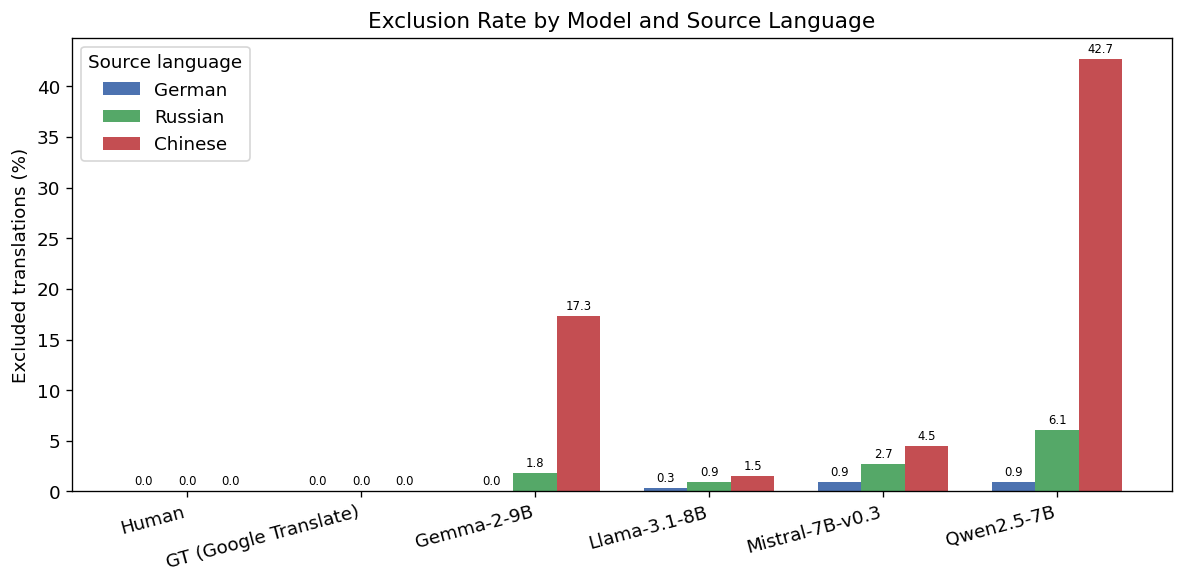

In [14]:
# Exclusion breakdown by model and source language (truncation / language drift / duplicate reference)
excluded_all = pd.concat([
    df_gen_excluded[['model', 'source_lang']],
    df_human_excluded[['model', 'source_lang']],
    df_gt_excluded[['model', 'source_lang']],
], ignore_index=True)

total_all = pd.concat([
    pd.concat([df_gen, df_gen_excluded])[['model', 'source_lang']],
    pd.concat([df_human, df_human_excluded])[['model', 'source_lang']],
    pd.concat([df_gt, df_gt_excluded])[['model', 'source_lang']],
], ignore_index=True)

excl_counts = (excluded_all.groupby(['source_lang', 'model']).size()
               .unstack('model').reindex(index=LANG_ORDER, columns=MODEL_ORDER).fillna(0).astype(int))
total_counts = (total_all.groupby(['source_lang', 'model']).size()
                .unstack('model').reindex(index=LANG_ORDER, columns=MODEL_ORDER))
excl_pct = (excl_counts / total_counts * 100).round(2)

excl_counts.loc['Total'] = excl_counts.sum()
excl_pct.loc['Total'] = (excl_counts.loc['Total'] / total_counts.sum() * 100).round(2)

print('Excluded translations by source language x model (count):')
display(excl_counts)
print("\nExcluded translations by source language x model (% of that language/model's total):")
display(excl_pct)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(MODEL_ORDER))
width = 0.25
for i, lang in enumerate(LANG_ORDER):
    bars = ax.bar(x + (i - 1) * width, excl_pct.loc[lang], width, label=lang, color=LANG_COLORS[lang])
    ax.bar_label(bars, fmt='%.1f', fontsize=7, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, rotation=15, ha='right')
ax.set_ylabel('Excluded translations (%)')
ax.set_title('Exclusion Rate by Model and Source Language')
ax.legend(title='Source language')
plt.tight_layout()
plt.savefig(FIG_DIR / 'translation_generated_exclusion_by_model_lang.png', dpi=300, bbox_inches='tight')
plt.show()

## Length Distributions

In [15]:
df_all = pd.concat([
    df_gen[['prompt_id', 'source_lang', 'model', 'word_count', 'char_count']],
    df_human[['prompt_id', 'source_lang', 'model', 'word_count', 'char_count']],
    df_gt[['prompt_id', 'source_lang', 'model', 'word_count', 'char_count']],
], ignore_index=True)

length_summary = df_all.groupby('model')['word_count'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).reindex(MODEL_ORDER).round(1)
display(length_summary)

,count,mean,median,std,min,max
model,,,,,,
Human,669,433.1,307.0,475.3,53,4637
GT (Google Translate),200,390.0,286.5,403.6,56,4173
Gemma-2-9B,936,372.3,286.0,290.0,55,2154
Llama-3.1-8B,991,381.8,304.0,264.4,55,1702
Mistral-7B-v0.3,973,390.7,305.0,293.6,54,2366
Qwen2.5-7B,834,367.3,281.5,277.7,55,1720


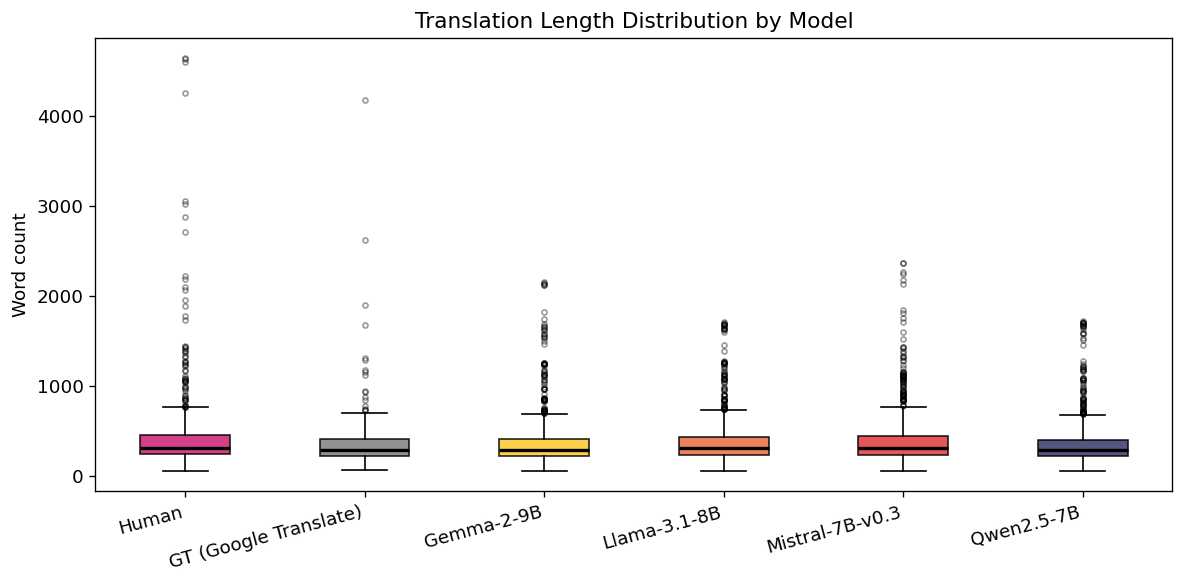

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
data = [df_all.loc[df_all.model == m, 'word_count'].values for m in MODEL_ORDER]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, tick_labels=MODEL_ORDER,
                 medianprops=dict(color='black', linewidth=2),
                 flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, m in zip(bp['boxes'], MODEL_ORDER):
    patch.set_facecolor(MODEL_COLORS[m])
    patch.set_alpha(0.85)

ax.set_ylabel('Word count')
ax.set_title('Translation Length Distribution by Model')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'translation_generated_length_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

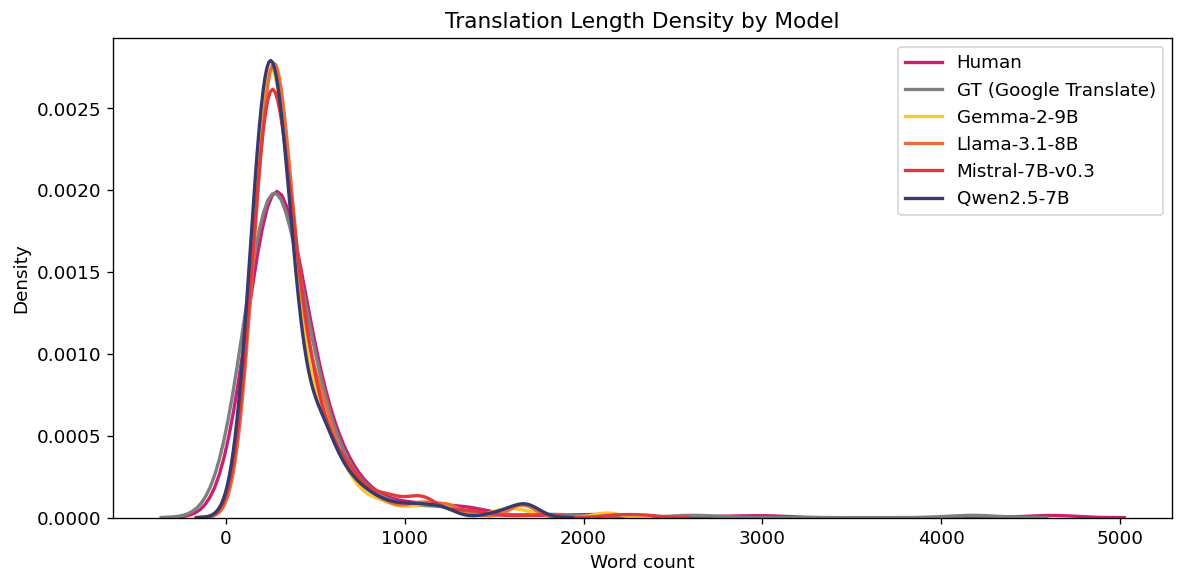

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
for m in MODEL_ORDER:
    sns.kdeplot(df_all.loc[df_all.model == m, 'word_count'], label=m,
                color=MODEL_COLORS[m], linewidth=2, ax=ax)
ax.set_xlabel('Word count')
ax.set_title('Translation Length Density by Model')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'translation_generated_length_kde.png', dpi=300, bbox_inches='tight')
plt.show()

## Within-Paragraph Length Variability

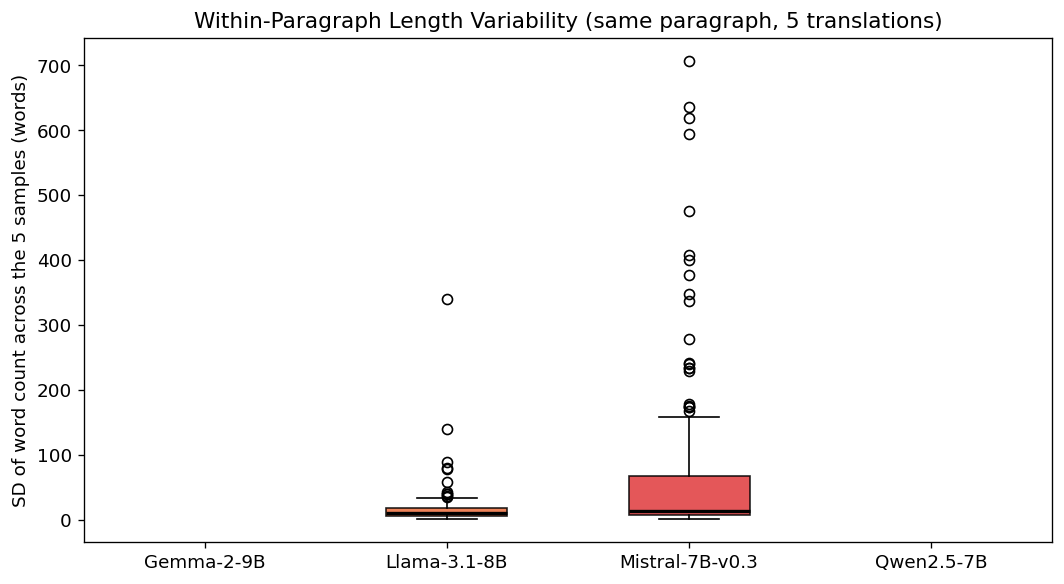

Mean within-paragraph SD by model:
model
Gemma-2-9B         10.6
Llama-3.1-8B       16.1
Mistral-7B-v0.3    63.6
Qwen2.5-7B         11.9
Name: within_prompt_sd, dtype: float64


In [18]:
within_std = (df_gen.groupby(['model', 'prompt_id'])['word_count']
              .std().reset_index().rename(columns={'word_count': 'within_prompt_sd'}))

fig, ax = plt.subplots(figsize=(9, 5))
data = [within_std.loc[within_std.model == m, 'within_prompt_sd'].values for m in GEN_ORDER]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, tick_labels=GEN_ORDER,
                 medianprops=dict(color='black', linewidth=2))
for patch, m in zip(bp['boxes'], GEN_ORDER):
    patch.set_facecolor(MODEL_COLORS[m])
    patch.set_alpha(0.85)

ax.set_ylabel('SD of word count across the 5 samples (words)')
ax.set_title('Within-Paragraph Length Variability (same paragraph, 5 translations)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'translation_generated_within_prompt_variability.png', dpi=300, bbox_inches='tight')
plt.show()

print('Mean within-paragraph SD by model:')
print(within_std.groupby('model')['within_prompt_sd'].mean().reindex(GEN_ORDER).round(1))

## Tokenizer Efficiency (tokens vs. words)

,mean,std
model,,
Gemma-2-9B,1.30,0.09
Llama-3.1-8B,1.28,0.07
Mistral-7B-v0.3,1.39,0.21
Qwen2.5-7B,1.28,0.08


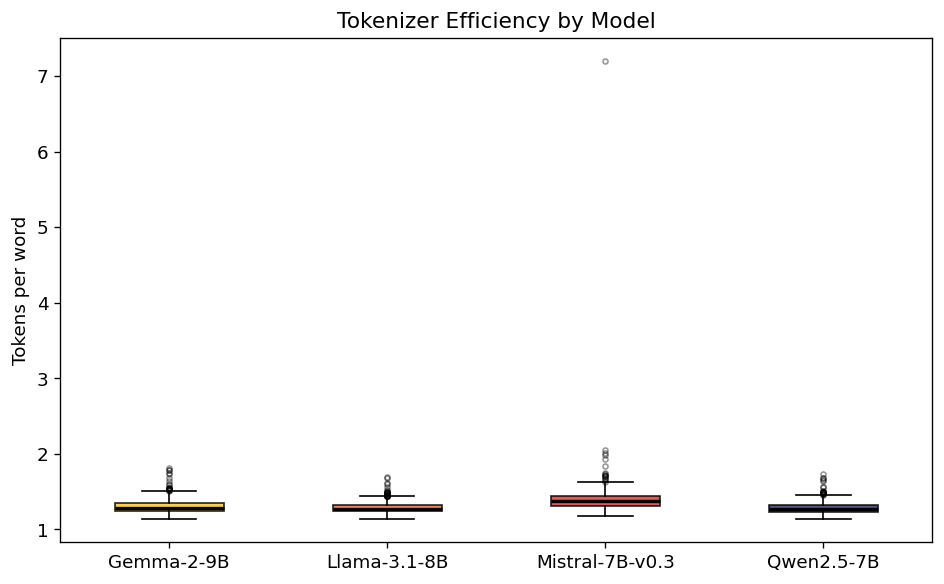

In [19]:
df_gen['tokens_per_word'] = df_gen['n_tokens'] / df_gen['word_count']
tok_summary = df_gen.groupby('model')['tokens_per_word'].agg(['mean', 'std']).reindex(GEN_ORDER).round(2)
display(tok_summary)

fig, ax = plt.subplots(figsize=(8, 5))
data = [df_gen.loc[df_gen.model == m, 'tokens_per_word'].values for m in GEN_ORDER]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, tick_labels=GEN_ORDER,
                 medianprops=dict(color='black', linewidth=2),
                 flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, m in zip(bp['boxes'], GEN_ORDER):
    patch.set_facecolor(MODEL_COLORS[m])
    patch.set_alpha(0.85)

ax.set_ylabel('Tokens per word')
ax.set_title('Tokenizer Efficiency by Model')
plt.tight_layout()
plt.savefig(FIG_DIR / 'translation_generated_tokens_per_word.png', dpi=300, bbox_inches='tight')
plt.show()

## Sentence Count Preservation (Structural Fidelity)

Does a translation keep roughly the same number of sentences as its source paragraph

In [20]:
sent_merged = df_gen.merge(df_meta[['prompt_id', 'source_n_sentences']], on='prompt_id')
sent_merged['sentence_delta'] = sent_merged['n_sentences'] - sent_merged['source_n_sentences']

sent_summary = sent_merged.groupby('model')['sentence_delta'].agg(['mean', 'std']).reindex(GEN_ORDER).round(2)
print('Sentence count delta (generated - source), by model:')
display(sent_summary)

corr_sent = sent_merged.groupby('model').apply(
    lambda g: g['source_n_sentences'].corr(g['n_sentences'])).reindex(GEN_ORDER)
print('\nPearson r(source n_sentences, generated n_sentences) by model:')
print(corr_sent.round(2))

Sentence count delta (generated - source), by model:


,mean,std
model,,
Gemma-2-9B,7.27,11.77
Llama-3.1-8B,6.72,13.08
Mistral-7B-v0.3,8.73,14.79
Qwen2.5-7B,5.96,11.58



Pearson r(source n_sentences, generated n_sentences) by model:
model
Gemma-2-9B         0.76
Llama-3.1-8B       0.66
Mistral-7B-v0.3    0.57
Qwen2.5-7B         0.78
dtype: float64


## Source Length vs. Translation Length

Pearson r(source char length, translation word length) by source language:
source_lang
German     0.87
Russian    0.96
Chinese    0.88
dtype: float64


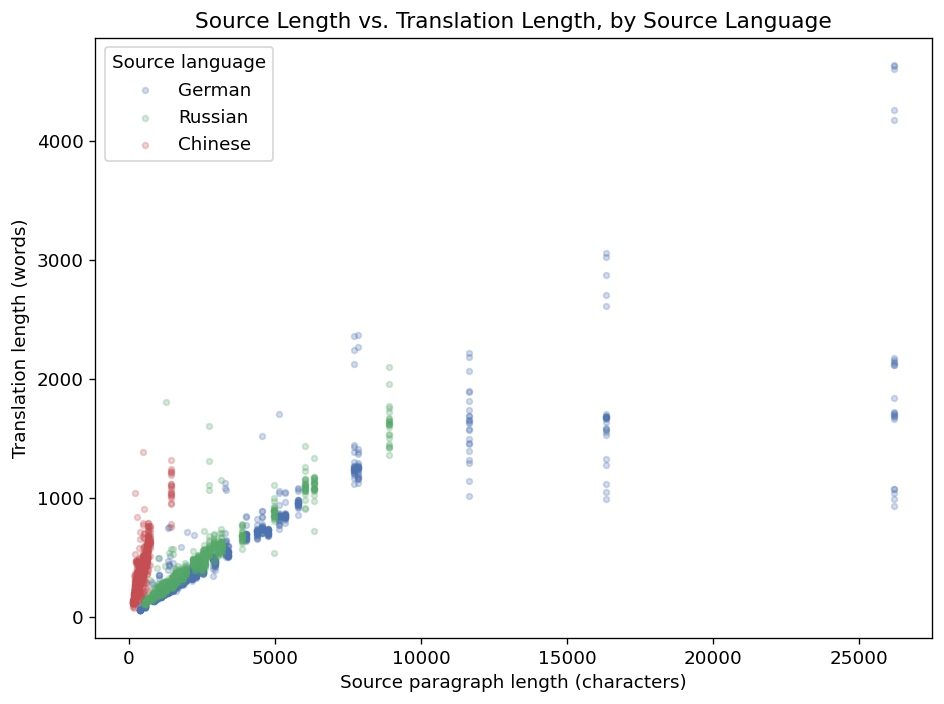

In [21]:
# Source length in characters (see note above on why word counts don't work for Chinese)
source_lens = df_meta[['prompt_id', 'source_char_count']]
merged = df_all.merge(source_lens, on='prompt_id')

print('Pearson r(source char length, translation word length) by source language:')
print(merged.groupby('source_lang').apply(lambda g: g['source_char_count'].corr(g['word_count']))
      .reindex(LANG_ORDER).round(2))

fig, ax = plt.subplots(figsize=(8, 6))
for lang in LANG_ORDER:
    sub = merged[merged.source_lang == lang]
    ax.scatter(sub['source_char_count'], sub['word_count'], alpha=0.25, s=12,
               color=LANG_COLORS[lang], label=lang)
ax.set_xlabel('Source paragraph length (characters)')
ax.set_ylabel('Translation length (words)')
ax.set_title('Source Length vs. Translation Length, by Source Language')
ax.legend(title='Source language')
plt.tight_layout()
plt.savefig(FIG_DIR / 'translation_generated_source_vs_translation_length.png', dpi=300, bbox_inches='tight')
plt.show()

## Length Ratio by Source Language

Character-based expansion ratio (translation chars / source chars) puts German, Russian and Chinese on the same scale, unlike a word-count ratio (meaningless for Chinese).

model,Human,GT (Google Translate),Gemma-2-9B,Llama-3.1-8B,Mistral-7B-v0.3,Qwen2.5-7B
source_lang,,,,,,
German,0.98,0.90,0.90,0.91,0.90,0.89
Russian,1.15,1.09,1.09,1.09,1.06,1.07
Chinese,4.89,4.33,4.68,5.14,4.84,4.54


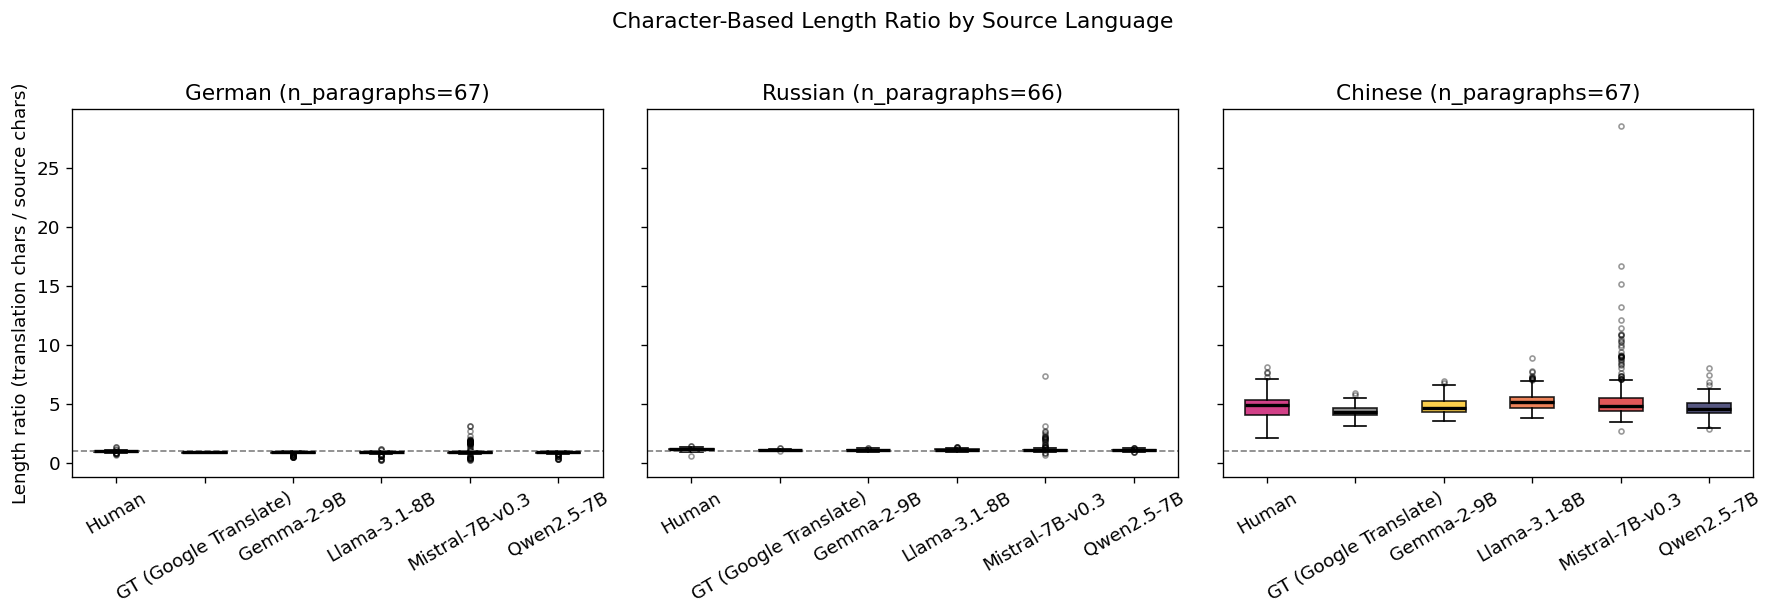

In [22]:
ratio_df = df_all.merge(df_meta[['prompt_id', 'source_char_count']], on='prompt_id')
ratio_df['length_ratio'] = ratio_df['char_count'] / ratio_df['source_char_count']

ratio_summary = (ratio_df.groupby(['source_lang', 'model'])['length_ratio'].median()
                  .unstack('model').reindex(index=LANG_ORDER, columns=MODEL_ORDER).round(2))
display(ratio_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, lang in zip(axes, LANG_ORDER):
    sub = ratio_df[ratio_df.source_lang == lang]
    data = [sub.loc[sub.model == m, 'length_ratio'].values for m in MODEL_ORDER]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5, tick_labels=MODEL_ORDER,
                     medianprops=dict(color='black', linewidth=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.4))
    for patch, m in zip(bp['boxes'], MODEL_ORDER):
        patch.set_facecolor(MODEL_COLORS[m])
        patch.set_alpha(0.85)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'{lang} (n_paragraphs={sub.prompt_id.nunique()})')
    ax.tick_params(axis='x', labelrotation=30)
axes[0].set_ylabel('Length ratio (translation chars / source chars)')
fig.suptitle('Character-Based Length Ratio by Source Language', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'translation_generated_length_ratio_by_language.png', dpi=300, bbox_inches='tight')
plt.show()

## Qualitative Samples: One Paragraph per Source Language, Across All Models

In [23]:
example_ids = (df_meta.drop_duplicates('source_lang')
               .set_index('source_lang')['prompt_id'].reindex(LANG_ORDER).tolist())

for example_id in example_ids:
    row = df_meta.loc[df_meta.prompt_id == example_id].iloc[0]
    n_human_refs = (df_human.prompt_id == example_id).sum()
    print(f'{"="*80}\nPROMPT_ID: {example_id}  |  BOOK: {row.book_id}  |  SOURCE LANG: {row.source_lang}  '
          f'({n_human_refs} human translators available, showing 1)')
    print('SOURCE:', row.source_text[:300] + ('...' if len(row.source_text) > 300 else ''))
    print()

    sources_to_show = [
        ('Human', df_human.loc[df_human.prompt_id == example_id, 'text'].iloc[0]),
        ('GT (Google Translate)', df_gt.loc[df_gt.prompt_id == example_id, 'text'].iloc[0]),
    ]
    for key, label in MODEL_LABELS.items():
        if key in ('human', 'gt'):
            continue
        # Take the lowest surviving sample_idx: sample 0 may have been dropped during filtering
        sub = df_gen.loc[(df_gen.model_key == key) & (df_gen.prompt_id == example_id)].sort_values('sample_idx')
        text = sub['text'].iloc[0] if len(sub) else None
        sources_to_show.append((label, text))

    for label, text in sources_to_show:
        if text is None:
            print(f'--- {label}: no surviving sample for this paragraph after filtering ---\n')
            continue
        print(f'--- {label} ({len(text.split())} words) ---')
        print(text[:400] + ('...' if len(text) > 400 else ''))
        print()
    print()

PROMPT_ID: par3_0001  |  BOOK: the_trial_de  |  SOURCE LANG: German  (4 human translators available, showing 1)
SOURCE: K. wartete während der nächsten Woche von Tag zu Tag auf eine neuerliche Verständigung, er konnte nicht glauben, daß man seinen Verzicht auf Verhöre wörtlich genommen hatte, und als die erwartete Verständigung bis Samstagabend wirklich nicht kam, nahm er an, er sei stillschweigend in das gleiche Hau...

--- Human (232 words) ---
K. waited from day to day throughout the following week for further notification; he couldn’t believe they had taken his waiver of interrogations literally, and when the expected notification had not arrived by Saturday evening, he took it as an implicit summons to appear again in the same building at the same time. So he returned on Sunday, but this time he went straight up the stairs and along t...

--- GT (Google Translate) (227 words) ---
During the next week K. waited day by day for a new understanding, he could not believe that his waive

## Summary

In [24]:
summary = length_summary.copy()
summary['truncated_%'] = quality_df['truncated_%'].reindex(MODEL_ORDER)
summary['non_english_%'] = lang_tab['non_english_%']
summary['exact_dup_%'] = dup_pct

summary.to_csv(FIG_DIR / 'translation_generated_summary_stats.csv')
display(summary)

,count,mean,median,std,min,max,truncated_%,non_english_%,exact_dup_%
model,,,,,,,,,
Human,669,433.1,307.0,475.3,53,4637,NaN,0.0,0.0
GT (Google Translate),200,390.0,286.5,403.6,56,4173,NaN,0.0,0.0
Gemma-2-9B,936,372.3,286.0,290.0,55,2154,0.0,6.4,0.0
Llama-3.1-8B,991,381.8,304.0,264.4,55,1702,0.1,0.8,0.0
Mistral-7B-v0.3,973,390.7,305.0,293.6,54,2366,0.4,2.3,0.0
Qwen2.5-7B,834,367.3,281.5,277.7,55,1720,0.1,16.6,0.0
